# Two-link manipulator — decoupling matrix $|\\det A|$ over output space (rebuttal figure)

Generates `detA_manip.png`: end-effector output-space scatter over $\\mathcal{X}_S\\setminus\\mathcal{X}_T$ colored by $|\\det A|\\propto\\sin q_2$, in the `make_paper_figs` style. Uses the decoupling-check region (elbow `MARGIN`).

Adjust the **parameter** cell, then run all.


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---- output directory (author_response/figs); edit if your tree differs ----
OUT = "/Users/jianqiang/Documents/Overleaf_Github_Sync/Reach-avoid-MPC/LCSS_Revsion/author_response/figs"
os.makedirs(OUT, exist_ok=True)

# ---- make_paper_figs canvas + palette + fonts (keep consistent with the paper) ----
PX = 1 / 100.0
FIGSIZE = (650 * PX, 600 * PX)  # 6.5 x 6.0 in  == make_paper_figs success-rate figs
FS_P = 30  # axis-label base font
C_SAFE_LINE, C_SAFE_FILL = "#2166ac", "#e6f2ff"
C_TGT_LINE, C_TGT_FILL = "#d6604d", "#fee0d2"


def draw_sets(ax, G1, G2, Zsafe, Ztgt, tgt_lw=2):
    ax.contourf(
        G1, G2, Zsafe, levels=[0, np.inf], colors=[C_SAFE_FILL], alpha=0.3, zorder=1
    )
    ax.contour(G1, G2, Zsafe, levels=[0], colors=[C_SAFE_LINE], linewidths=2, zorder=4)
    ax.contourf(
        G1, G2, Ztgt, levels=[-np.inf, 0], colors=[C_TGT_FILL], alpha=1.0, zorder=2
    )
    ax.contour(
        G1, G2, Ztgt, levels=[0], colors=[C_TGT_LINE], linewidths=tgt_lw, zorder=5
    )

In [17]:
# --- manipulator model; A = J(x) Minv(x2);  output = end-effector (fk) ---
L1, L2 = 4.0, 4.0
MM1, MM2 = 1.0, 1.0
LC1, LC2 = 2.0, 2.0
II1, II2 = 0.02, 0.02


def fk(x1, x2):
    x5 = x1 + x2
    return L1 * np.cos(x1) + L2 * np.cos(x5), L1 * np.sin(x1) + L2 * np.sin(x5)


def safe_poly(y1, y2):
    return -((4 * (y1 - 2) - 2 * y2**3) ** 2) + 0.8 * y2**3 + 10


def target_poly(y1, y2):
    return ((y1 - 5.5) ** 2 / 1.2**2) + ((y2 - 1.8) ** 2 / 0.4**2) - 2


def absdetA(x1, x2):
    x5 = x1 + x2
    c2 = np.cos(x2)
    M11 = II1 + II2 + MM1 * LC1**2 + MM2 * (L1**2 + LC2**2 + 2 * L1 * LC2 * c2)
    M12 = MM2 * (LC2**2 + L1 * LC2 * c2) + II2
    M22 = (MM2 * LC2**2 + II2) * np.ones_like(x2)
    detM = M11 * M22 - M12**2
    iM11, iM12, iM22 = M22 / detM, -M12 / detM, M11 / detM
    J11 = -L1 * np.sin(x1) - L2 * np.sin(x5)
    J12 = -L2 * np.sin(x5)
    J21 = L1 * np.cos(x1) + L2 * np.cos(x5)
    J22 = L2 * np.cos(x5)
    A11 = J11 * iM11 + J12 * iM12
    A12 = J11 * iM12 + J12 * iM22
    A21 = J21 * iM11 + J22 * iM12
    A22 = J21 * iM12 + J22 * iM22
    return np.abs(A11 * A22 - A12 * A21)

In [18]:
# ===== parameters (edit me) =====
N = 1_500_000  # number of samples
SEED = 42
MARGIN = 0.3  # elbow margin: x2 in [MARGIN, pi-MARGIN] (decoupling-check region)
XLIM = (-1.0, 5.5)  # output-space view (matches the paper figure)
YLIM = (-4.0, 2.5)
S_PT = 8  # scatter marker size

In [19]:
rng = np.random.default_rng(SEED)
sx1 = rng.uniform(-np.pi, np.pi, N)
sx2 = rng.uniform(MARGIN, np.pi - MARGIN, N)
sy1, sy2 = fk(sx1, sx2)
absdet = absdetA(sx1, sx2)
in_RA = (safe_poly(sy1, sy2) >= 0) & (target_poly(sy1, sy2) > 0)
print(
    f"{int(in_RA.sum())} samples in X_S\\X_T, "
    f"|det A| in [{absdet[in_RA].min():.3f}, {absdet[in_RA].max():.3f}]"
)

68573 samples in X_S\X_T, |det A| in [0.203, 0.246]


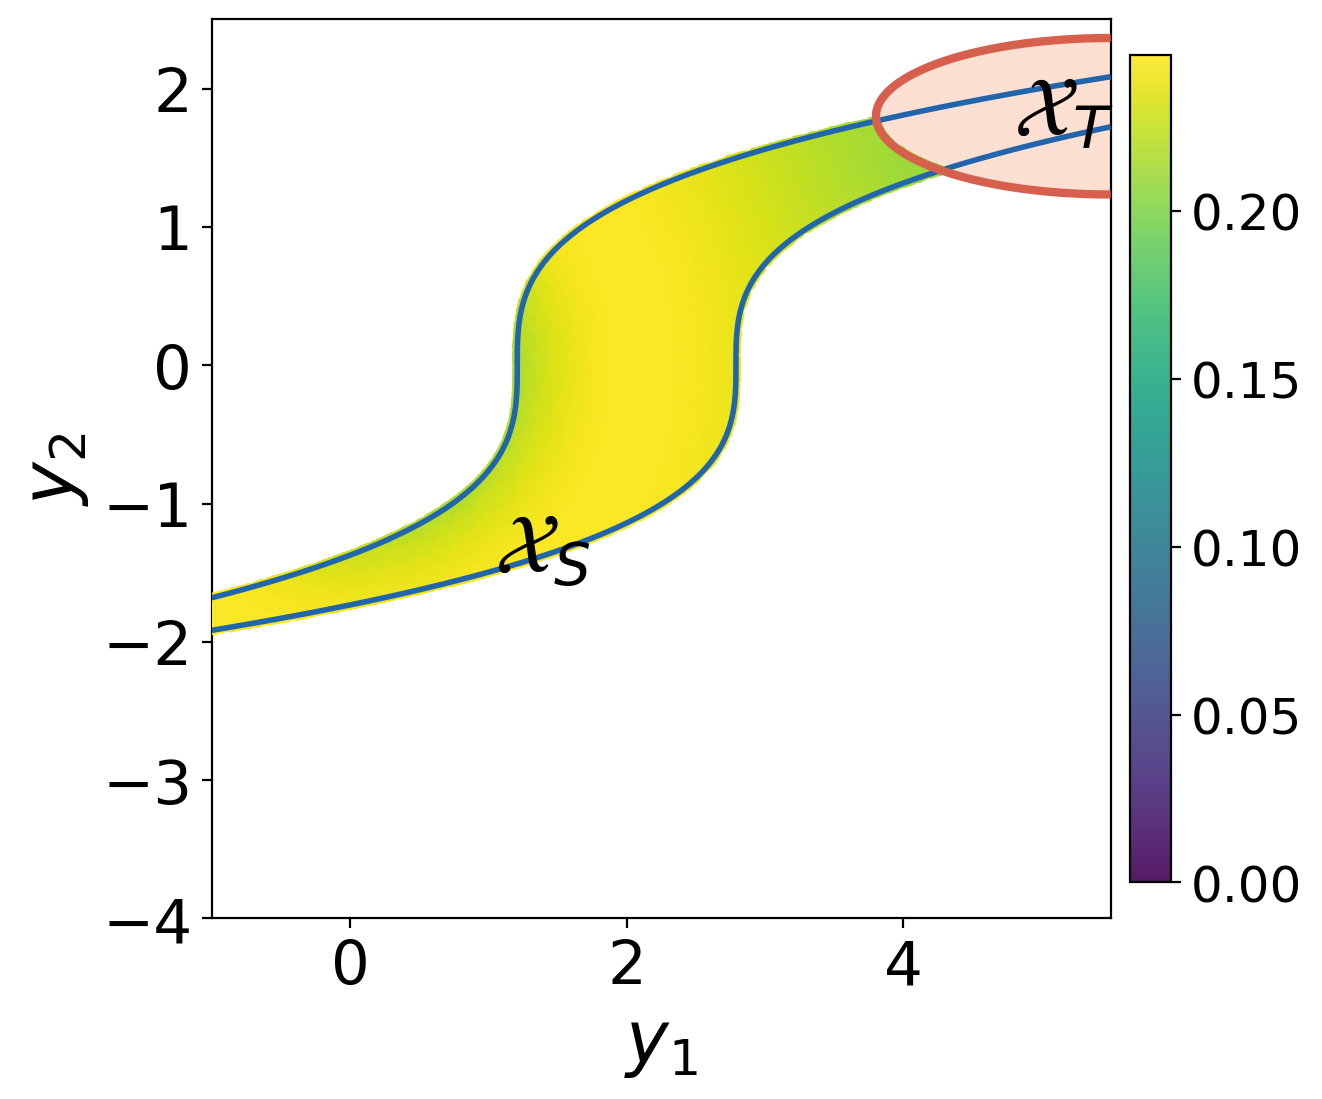

saved /Users/jianqiang/Documents/Overleaf_Github_Sync/Reach-avoid-MPC/LCSS_Revsion/author_response/figs/detA_manip.png


In [20]:
g1 = np.linspace(XLIM[0], XLIM[1], 500)
g2 = np.linspace(YLIM[0], YLIM[1], 500)
G1, G2 = np.meshgrid(g1, g2)
fig, ax = plt.subplots(figsize=FIGSIZE, layout="constrained")
fig.set_dpi(200)
draw_sets(ax, G1, G2, safe_poly(G1, G2), target_poly(G1, G2), tgt_lw=3)
sc = ax.scatter(
    sy1[in_RA],
    sy2[in_RA],
    c=absdet[in_RA],
    s=S_PT,
    cmap="viridis",
    vmin=0,
    alpha=0.9,
    zorder=3,
)
ax.text(1.05, -1.5, r"$\mathcal{X}_S$", fontsize=FS_P, zorder=100)
ax.text(4.8, 1.67, r"$\mathcal{X}_T$", fontsize=FS_P, zorder=100)
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
# cb.set_label(r"$|\det\mathbf{A}| \propto \sin q_2$", fontsize=FS_P - 6)
cb.ax.tick_params(labelsize=18)
ax.set_xlabel(r"$y_1$", fontsize=FS_P - 4)
ax.set_ylabel(r"$y_2$", fontsize=FS_P - 4)
ax.xaxis.set_tick_params(labelsize=22)
ax.yaxis.set_tick_params(labelsize=22)
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.set_aspect("equal")
fig.savefig(os.path.join(OUT, "detA_manip.png"), dpi=200, bbox_inches="tight")
plt.show()
print("saved", os.path.join(OUT, "detA_manip.png"))